In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Bidirectional, LSTM, Dense

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
data = df['Temp'].values.reshape(-1, 1)

In [5]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [7]:
def create_dataset(series, time_step=30):
    X, y = [], []
    for i in range(time_step, len(series)):
        X.append(series[i-time_step:i])
        y.append(series[i])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(data_scaled, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [9]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [11]:
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=False), input_shape=(time_step, 1)))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
model.summary()


C:\Users\yasmi\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0434 - val_loss: 0.0099
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0111 - val_loss: 0.0095
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0111 - val_loss: 0.0090
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0108 - val_loss: 0.0088
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0104 - val_loss: 0.0087
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0104 - val_loss: 0.0085
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0102 - val_loss: 0.0081
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0094 - val_loss: 0.0080
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0097 - val_loss: 0.0076
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0094 - val_loss: 0.0074
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0094 - val_loss: 0.0072
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

In [15]:
y_pred = model.predict(X_test)
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


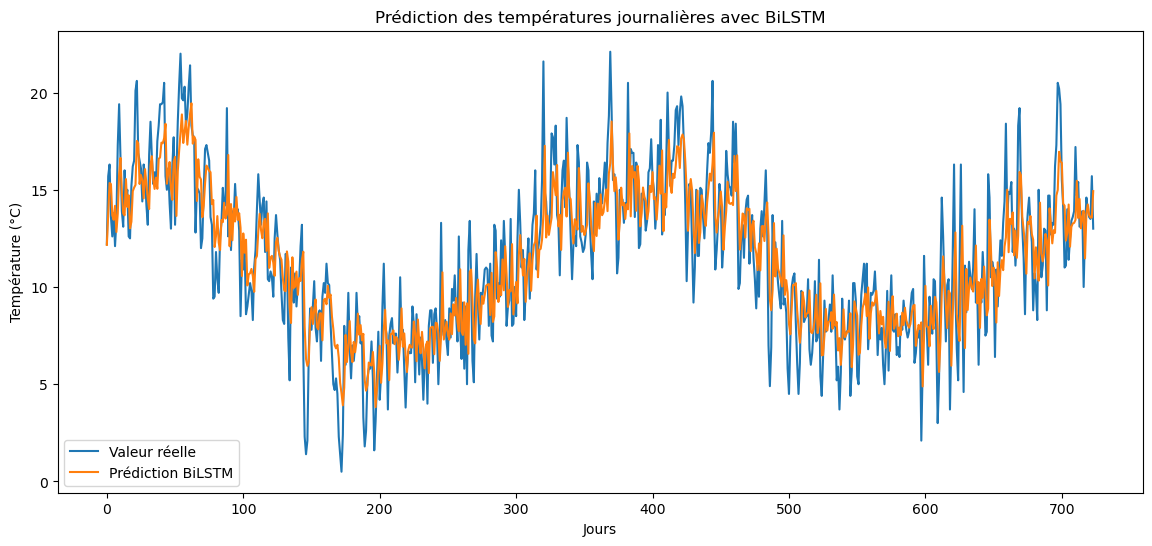

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_rescaled, label='Valeur réelle')
plt.plot(y_pred_rescaled, label='Prédiction BiLSTM')
plt.title('Prédiction des températures journalières avec BiLSTM')
plt.xlabel('Jours')
plt.ylabel('Température (°C)')
plt.legend()
plt.show()